Millions of 3-D points: the multiscale backend
==============================================

**When to use:** balanced OT between 3-D point clouds of a million points or more, when you need the value or the
potentials. The multiscale backend is forward only: it returns no gradients.

**What you will see:** a sphere shell and a torus of 1,000,000 points each, the potential on the shell, where 300
random shell points are sent, and how the time grows with the number of points for the dense symmetric backend
and the multiscale backend. Its options and limits are described in API.md (multiscale backend).

Source: [plot_multiscale_3d.py](plot_multiscale_3d.py) · [Gallery](../README.md)

Reference figures and quoted results come from previous script runs. They are reading aids, not outputs from an execution of this notebook.

Install `pip install --upgrade 'flash-sinkhorn[notebooks]'`, clone this repository for the example files, and start `jupyter lab` from the checkout. Select its Python environment, then run the cells in order on an NVIDIA CUDA GPU. The setup cell finds the checkout from the repository root or this notebook's folder. The solver comes from the installed package. Running all cells prints fresh results and displays new figures; it also replaces the source's saved images. The scale examples retain the script's full problem sizes.

In [ ]:
# Find this checkout when Jupyter starts at its root or in a notebook folder.
import os
import sys
from pathlib import Path

for _candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (_candidate / 'examples/scale/plot_multiscale_3d.py').is_file() and (_candidate / "torch-ext/flash_sinkhorn").is_dir():
        _notebook_root = _candidate
        break
else:
    raise RuntimeError("Start Jupyter inside the flash-sinkhorn repository checkout.")

os.chdir(_notebook_root)
# Locate shared example helpers; import the solver from the installed package.
for _path in reversed([_notebook_root / "examples", _notebook_root]):
    if str(_path) in sys.path:
        sys.path.remove(str(_path))
    sys.path.insert(0, str(_path))
__file__ = str(_notebook_root / 'examples/scale/plot_multiscale_3d.py')

# Display the saved PNG/GIF files explicitly, including figures closed by the source.
import matplotlib
matplotlib.use("Agg")

Setup
-----

In [ ]:
import math
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from flash_sinkhorn import SamplesLoss

sys.path.append(str(Path(__file__).resolve().parents[1]))  # the gallery's shared helpers
from _plotting import (ARROW, SOURCE, TARGET, dense_size, images_dir, require_cuda, save, subsample,  # noqa: E402
                       table, timed, to_numpy)
from _transport import barycentric_targets  # noqa: E402

device = require_cuda()
generator = torch.Generator(device=device).manual_seed(0)


def shell(n):
    """n points near the unit sphere."""
    v = torch.randn(n, 3, device=device, generator=generator)
    return v / v.norm(dim=1, keepdim=True) * (1 + 0.02 * torch.randn(n, 1, device=device, generator=generator))


def torus(n, major=0.8, minor=0.3):
    """n points in a solid torus around the z axis."""
    u = 2 * math.pi * torch.rand(n, device=device, generator=generator)
    v = 2 * math.pi * torch.rand(n, device=device, generator=generator)
    r = minor * torch.rand(n, device=device, generator=generator).sqrt()
    return torch.stack([(major + r * v.cos()) * u.cos(), (major + r * v.cos()) * u.sin(), r * v.sin()], dim=1)

A million points on each side
-----------------------------
``backend="multiscale"`` solves on coarse cells first and refines where the plan needs it. It returns once a
sampled check finds the marginal residual below ``tol`` (default 5e-3), and warns otherwise. It takes balanced
problems, debiasing, ``half_cost`` and ``potentials=True``. It tunes its own kernels: ``autotune`` does not
apply to it.

In [ ]:
n = 1_000_000
x, y = shell(n), torus(n)
print(dense_size(n, n))
blur = 0.05
multiscale = SamplesLoss(blur=blur, half_cost=True, debias=False, backend="multiscale", potentials=True)
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    f, g = timed("multiscale potentials", lambda: multiscale(x, y))
print("tol confirmed" if not caught else f"warning: {caught[0].message}")

Where the points go
-------------------
The potentials define the plan as in the basics example. Its rows are independent, so the barycentric targets
of 300 random shell points need only those rows: two passes over 300 x 1,000,000 pairs, for the row masses and
the weighted target positions. The solver works on centred, TF32-rounded coordinates while the helper recomputes
FP32 costs on the original points, so the arrows approximate the solved plan.

In [ ]:
a = torch.full((n,), 1.0 / n, device=device)
idx = subsample(n, 300, device=device)
targets = timed("barycentric targets of 300 points",
                lambda: barycentric_targets(x[idx], y, f[idx], g, a[idx], a, eps=blur**2, cost_scale=0.5))

Time against the number of points
---------------------------------
The dense symmetric backend evaluates all n x n pairs at every iteration; the multiscale backend works on coarse
cells and on the pairs the plan needs. Each size is timed on its second call; the first may compile kernels.

In [ ]:
def seconds(loss, points):
    xs, ys = shell(points), torus(points)
    loss(xs, ys)
    torch.cuda.synchronize()
    start = time.perf_counter()
    loss(xs, ys)
    torch.cuda.synchronize()
    return time.perf_counter() - start


dense = SamplesLoss(blur=blur, half_cost=True, debias=False, backend="symmetric", autotune=False)
value = SamplesLoss(blur=blur, half_cost=True, debias=False, backend="multiscale")
dense_sizes, multiscale_sizes = [100_000, 300_000, 1_000_000], [300_000, 1_000_000, 2_000_000, 4_000_000]
dense_times = [seconds(dense, size) for size in dense_sizes]
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    multiscale_times = [seconds(value, size) for size in multiscale_sizes]
for name, sizes, times in (("dense", dense_sizes, dense_times), ("multiscale", multiscale_sizes, multiscale_times)):
    print(f"{name}: " + ", ".join(f"{size:,} points {t:.1f} s" for size, t in zip(sizes, times)))
print(f"multiscale warnings: {len(caught)}")

Figure
------
20,000 random points of each cloud. Left: the shell coloured by its potential f. Middle: arrows from 300 shell
points (red) to their barycentric targets in the torus (blue). Right: time against the number of points.

In [ ]:
show = subsample(n, 20_000, seed=1, device=device)
xs, ys = to_numpy(x[show]), to_numpy(y[show])
fig = plt.figure(figsize=(14.0, 4.6))
ax_pot = fig.add_subplot(1, 3, 1, projection="3d")
image = ax_pot.scatter(xs[:, 0], xs[:, 1], xs[:, 2], c=to_numpy(f[show]), s=0.5, cmap="viridis")
fig.colorbar(image, ax=ax_pot, fraction=0.03, pad=0.02, label="f")
ax_pot.set_title("shell, coloured by its potential")
ax_map = fig.add_subplot(1, 3, 2, projection="3d")
ax_map.scatter(ys[:, 0], ys[:, 1], ys[:, 2], s=0.3, color=TARGET, alpha=0.2)
start_points, steps = to_numpy(x[idx]), to_numpy(targets - x[idx])
ax_map.scatter(start_points[:, 0], start_points[:, 1], start_points[:, 2], s=4, color=SOURCE)
ax_map.quiver(start_points[:, 0], start_points[:, 1], start_points[:, 2], steps[:, 0], steps[:, 1], steps[:, 2],
              color=ARROW, linewidth=0.6, arrow_length_ratio=0.1)
ax_map.set_title("300 shell points (red) to their targets")
for ax in (ax_pot, ax_map):
    ax.set_box_aspect((1, 1, 1))
    ax.set_axis_off()
ax_time = fig.add_subplot(1, 3, 3)
dense_at, multiscale_at = dict(zip(dense_sizes, dense_times)), dict(zip(multiscale_sizes, multiscale_times))
table(ax_time, ["points per cloud", "dense symmetric", "multiscale"],
      [[f"{size:,}", f"{dense_at[size]:.1f} s" if size in dense_at else "-",
        f"{multiscale_at[size]:.1f} s" if size in multiscale_at else "-"]
       for size in sorted(set(dense_sizes) | set(multiscale_sizes))],
      title=f"seconds per value ({torch.cuda.get_device_name()})")
fig.tight_layout()
save(fig, images_dir(__file__), "multiscale_3d")
plt.show()

In [ ]:
from IPython.display import Image as _NotebookImage, display as _notebook_display
_notebook_display(_NotebookImage(filename=str(_notebook_root / 'examples/scale/images/multiscale_3d.png')))
# Release figure managers so repeated runs do not accumulate open figures.
import matplotlib.pyplot as _notebook_plt
_notebook_plt.close("all")

**Reference figure from previous script runs.**

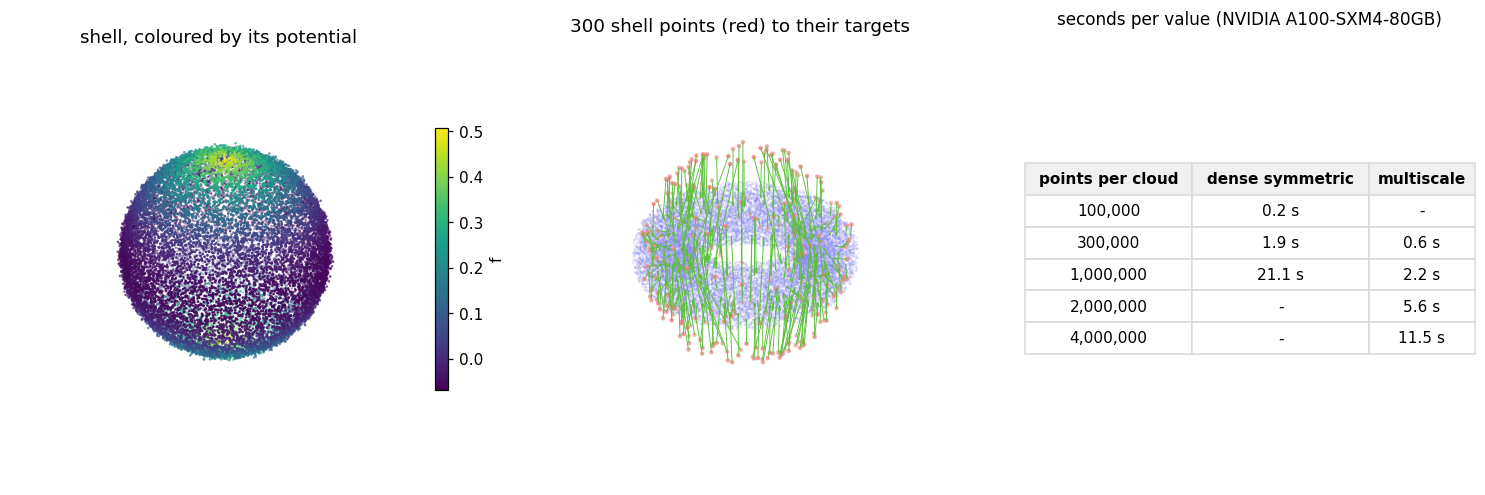